# Stationary Time Series

In this notebook we introduce **stationary time series** as series that don't vary with time, and as such, are suitable for forcasting. Stationary time series have been widely researched. They are used as building blocks for more complex models.

**Iid noise**, **white noise** and **white Gaussian noise** are introduced as importatnt stationary time series.

We generated three **synthetic stationary time series datasets** using `numpy`-s `random` module.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Definition of Stationarity

**Definition:** Time series $\{X_t\}$ is **(weakly) stationary** if:
1. it has constant mean function $\mu_t=E[X_t]=\mu$
2. for each lag $h$ covarience function $\gamma_X(t, t+h)$ is independent of time $t$.

By plugging $h=0$ in definition above we get:
$$\gamma_X(0,0)=\gamma_X(1,1)=\gamma_X(2, 2)=...$$

Since $\gamma_X(t, t)=Cov(X_t, X_t)=Var[X_t]=\sigma^2_t$ we conclude that variance function of stationary time series is constant:
$$ \sigma^2 = \sigma^2_0 = \sigma^2_1 = \sigma^2_2 =... $$

Also, because covariance doesn't deppend on time $t$ if we fix lag $h$ and plug different values $t=0, 1, 2...$:
$$ \gamma(0,h)=\gamma(1,1+h)=\gamma(2,2+h)=...$$
We conclude that covariance function for fixed lag $h$ have the constant value, so we define autocovariance function.

**Definition:** Let $\{X_t\}$ be a stationary time series.

**Autocovariance function** $\gamma_X(\cdot)$ at lag $h$ defined is:
$$
\gamma_X(h)=\gamma_X(t, t+h)=Cov[X_t, X_{t+h}], \forall h
$$
**Autocorrelation function** $\rho_X(\cdot)$ at lag $h$ defined is:
$$
\rho_X(h)=\rho_X(t, t+h)=Corr[X_t, X_{t+h}], \forall h
$$


## Important Stationary Time series

### 1. iid Noise

**Definition:** If elements of time series $\{X_t\}$ are independent and identically distributed random variables with zero mean, we say that $\{X_t\}$ is **iid noise** and denote it as $\{X_t\} \sim \text{IID} (0,\sigma^2)$.

By assumed identical distribution,
$$\gamma_X(0)=Var[X_t]=\sigma^2 $$
$$\rho_X(0)=1 $$

By assumed independence,
$$\gamma_X(h)=0, \forall h \ne 0 $$
$$\rho_X(h)=0, \forall h \ne 0 $$

Iid noise is stationary time series.

**Example 1.** Let's sample $n=50$ observations of $\{X_t\} \sim \text{IID  }(0,1^2)$ where each element of time series has probability mass function:
$$
P\{X_t=x\}
=
\begin{cases}
\frac{1}{2}, & x = 1, \\
\frac{1}{2}, & x = -1
\end{cases}
$$

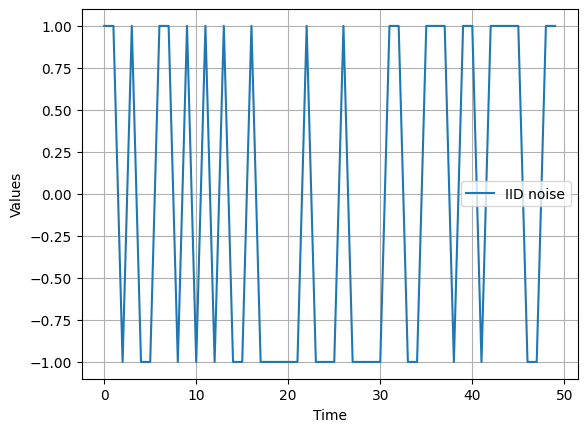

In [ ]:
# Generate the time axis with sequential numbers upto 50
t = np.arange(50)

# Sample 50 random values from set {0, 1}
x = np.random.randint(2, size=50)

# Change each 0 to -1
x = [-1 if i == 0 else 1 for i in x.tolist()]

# Plot the time series
plt.plot(t, x,
         label='IID noise')
plt.xlabel('Time')
plt.ylabel('Values')
plt.grid(True)
plt.legend()

If $\{X_t\} \sim \text{IID} (0,\sigma^2)$, it is NOT possible to predict $X_t$ given $X_{t-1}, X_{t-2}, ..., X_0$. This means that we cannot forecast iid noise.

### White Gaussian noise


**Definition:** If elements of iid noise $\{X_t\}$ follow normal distribution with zero mean and variance $\sigma^2$ we say $\{X_t\}$ is **white Gaussian noise** and denote it as $\{X_t\} \sim \text{IID  } \mathcal{N}(0,\sigma^2)$.

White Gaussian noise is stationary time series.

If $\{\epsilon_t\} \sim \text{IID } \mathcal{N}(0,\sigma^2)$, it is NOT possible to predict $\epsilon_t$ given $\epsilon_{t-1}, \epsilon_{t-2}, ..., \epsilon_0$. We cannot forecast white Gaussian noise.

In time series models $\epsilon_t$ represents new, unpredictable information at the time step $t$.

**Example 2.** Let's sample $n=100$ observations of Gaussian white noise $\{X_t\} \sim \text{IID  }\mathcal{N}(0,1^2)$

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-203683215.py:9: SyntaxWarning: invalid escape sequence '\m'
  label='100 draws from Gaussian white noise IID $\mathcal{N}(0,1^2)$')


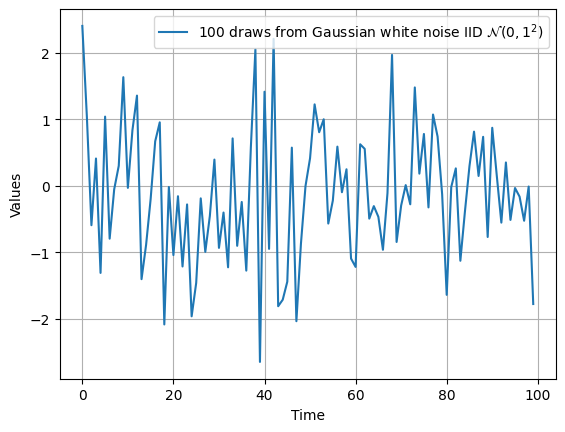

In [ ]:
# Generate the time axis with sequential numbers upto 100
t = np.arange(100)

# Sample 100 values from standard normal distribution
x = np.random.randn(100)

# Plot the time series
plt.plot(t, x,
         label='100 draws from Gaussian white noise IID $\mathcal{N}(0,1^2)$')
plt.xlabel('Time')
plt.ylabel('Values')
plt.grid(True)
plt.legend()

**Example 3.** Now let's sample $n=100$ observations of Gaussian white noise$\{X_t\} \sim \text{IID  }\mathcal{N}(0,(0.5)^2)$

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-1488850418.py:8: SyntaxWarning: invalid escape sequence '\m'
  label='100 draws from Gaussian white noise IID $\mathcal{N}(0,(0.5)^2)$')


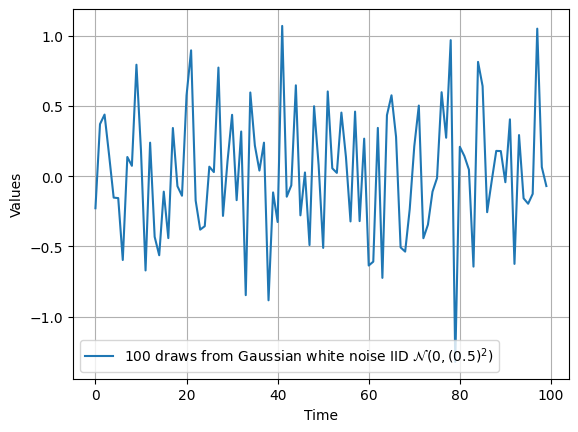

In [ ]:
# Generate the time axis with sequential numbers upto 100
t = np.arange(100)

# Sample 100 values from standard normal distribution
x = np.random.normal(loc=0, scale=0.5, size=100)

plt.plot(t, x,
         label='100 draws from Gaussian white noise IID $\mathcal{N}(0,(0.5)^2)$')
plt.xlabel('Time')
plt.ylabel('Values')
plt.grid(True)
plt.legend()

### White Noise

**Definition:** Time series $\{X_t\}$ is **white noise** if:
1. its elements are uncorrelated: $Corr(X_t, X_s)=0, \forall t \ne s$
2. mean function is zero function: $E[X_t]=0, \forall t$
3. variance function is constant $Var[X_t] = \sigma^2$
White noise time series is denoted as $\text{WN}(0, \sigma^2)$.

White noise is stationary time series.

White Gaussian noise is special type of iid noise, and iid noise is special type of white noise.

**Resources**:

*   Brockwell, P. J., & Davis, R. A. (2016). *Introduction to Time Series and Forecasting* (3rd ed.). Springer (pp. 6-18)


